In [1]:
import torch
from torchvision import datasets, transforms
data_dir = "./data"


transform = transforms.ToTensor()
trainset = datasets.MNIST(
    root=data_dir, 
    train=True,
    download=True,
    transform=transform
    )

testset = datasets.MNIST(
        root=data_dir,
        train=False,
        download=True,
        transform=transform
    )

In [2]:
all_images_train = torch.stack([trainset[i][0] for i in range(len(trainset))])
all_images_test = torch.stack([testset[i][0] for i in range(len(testset))])

#Calculate mean and std of the training and test datasets, for normalizaton

mean_train = all_images_train.mean().item()
std_train = all_images_train.std().item()
print(f"all_images_train - Media: {mean_train:.4f}, Std: {std_train:.4f}")

mean_test = all_images_test.mean().item()
std_test = all_images_test.std().item()
print(f"all_images_test - Media: {mean_test:.4f}, Std: {std_test:.4f}")

all_images_train - Media: 0.1307, Std: 0.3081
all_images_test - Media: 0.1325, Std: 0.3105


# Loading data

Loading data:
    - test
    - seed

Using compose to transform the data:
    . To tensor: 
        to convert the datasets into a tensor
    . Normalization
        

In [3]:

from torchvision import datasets, transforms

data_dir = "./data"

transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((mean_test,), (std_test,))
    ])

trainset = datasets.MNIST(
        root=data_dir,
        train=True,
        download=True,
        transform=transform
    )

testset = datasets.MNIST(
        root=data_dir,
        train=False,
        download=True,
        transform=transform
    )

In [4]:
def images_extractor(dataset):
    """
    Extrae las imágenes y etiquetas de un dataset de MNIST,
    y las devuelve como arrays de numpy.
    """
    images =  torch.stack([dataset[i][0] for i in range(len(dataset))])
    return images.numpy()


def labels_extractor(dataset):
    """
    Extrae las imágenes y etiquetas de un dataset de MNIST,
    y las devuelve como arrays de numpy.
    """
    labels = torch.tensor([dataset[i][1] for i in range(len(dataset))])
    return labels.numpy()

In [5]:
test_images = images_extractor(testset)
test_labels = labels_extractor(testset)

# Statistics 

## Mean and STD are suppose to be 0 an 1 since they are normalized. 

# Expected results after trainng

In [6]:

import numpy as np

print(f"mean = {test_images.mean():.4f}, std = {test_images.std():.4f}")

unique_t, counts_t = np.unique(test_labels, return_counts=True)

print("\nDistribution in TEST:")
for d, c in zip(unique_t, counts_t):
    print(f"  Digit {d}: {c} images")


mean = -0.0000, std = 1.0000

Distribution in TEST:
  Digit 0: 980 images
  Digit 1: 1135 images
  Digit 2: 1032 images
  Digit 3: 1010 images
  Digit 4: 982 images
  Digit 5: 892 images
  Digit 6: 958 images
  Digit 7: 1028 images
  Digit 8: 974 images
  Digit 9: 1009 images


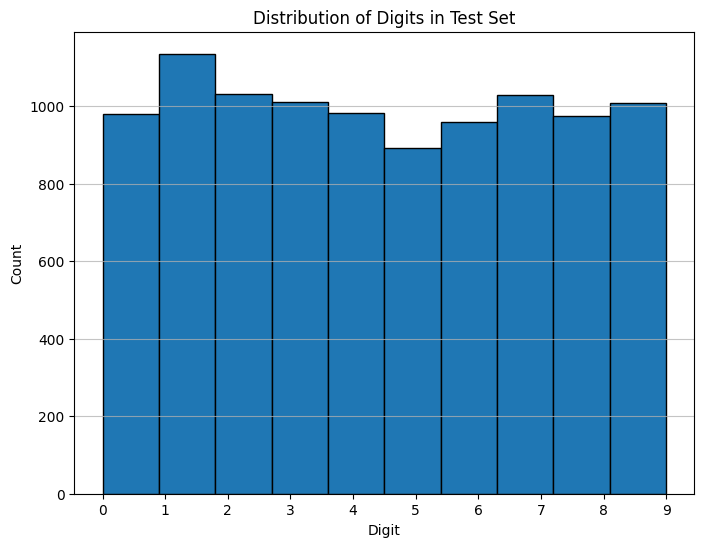

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.hist(test_labels, edgecolor='black')
plt.xticks(range(10))
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('Distribution of Digits in Test Set')
plt.grid(axis='y', alpha=0.75)
plt.savefig('../output/digit_distribution.png', dpi=150)
plt.show()


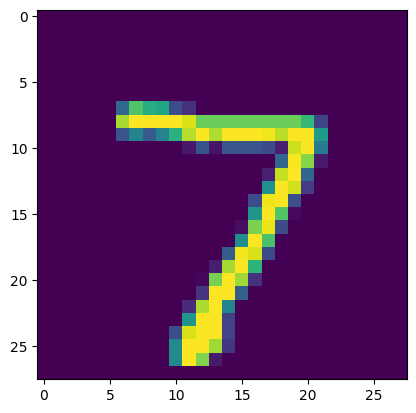

In [8]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(test_images[0,0])
plt.show()

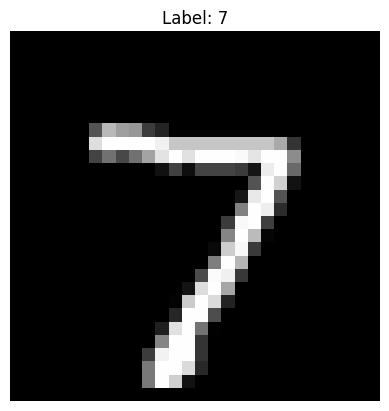

In [9]:
import matplotlib.pyplot as plt

plt.imshow(test_images[0, 0], cmap='gray')
plt.title(f"Label: {test_labels[0]}")
plt.axis('off')
plt.savefig(f'../output/sample_image_label_{test_labels[0]}.png', dpi=150)
plt.show()


(10000, 1, 28, 28)


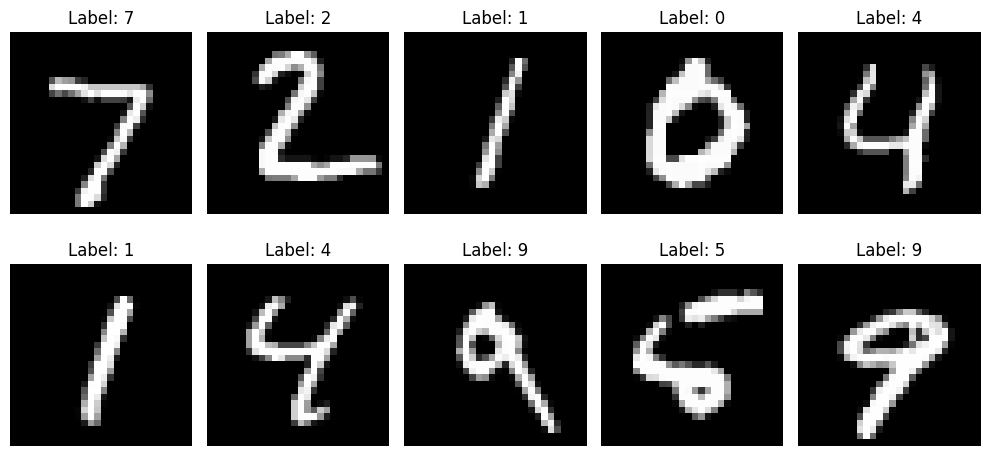

In [10]:
import matplotlib.pyplot as plt

print(test_images.shape)   

# test_images' shape is (N, 1, 28, 28)
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img = test_images[i, 0] if test_images.ndim == 4 else test_images[i]
    img_display = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img_display, cmap='gray')
    ax.set_title(f"Label: {test_labels[i]}")
    ax.axis('off')
plt.tight_layout()
plt.savefig('../output/sample_images.png', dpi=150)
plt.show()

# Modeling 
Definingn a Convolutional neural network (cnn)

In [11]:
test_images_cnn = test_images.reshape((-1, 28, 28, 1))
print(test_images_cnn.shape)

(10000, 28, 28, 1)


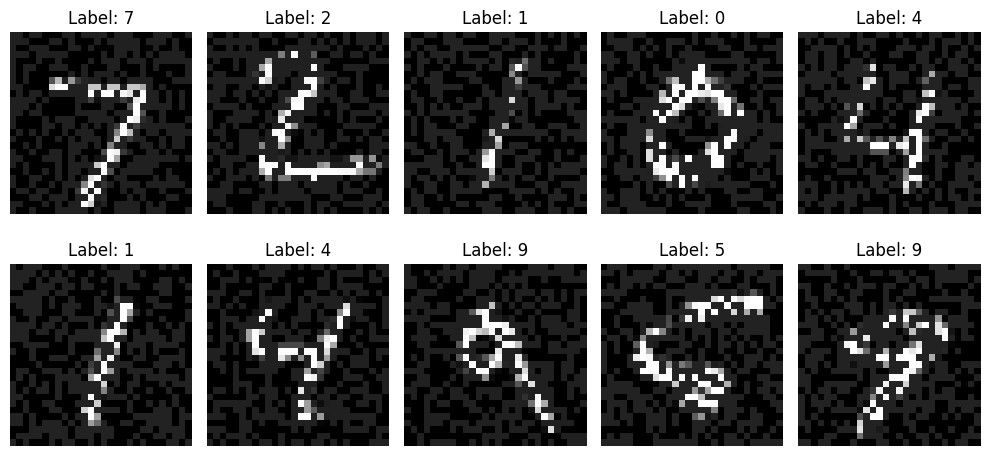

In [12]:
drop_prob = 0.5
drop_mask = np.random.rand(*test_images_cnn.shape) > drop_prob
test_images_dropped = test_images_cnn * drop_mask


plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = test_images_dropped[i, :, :, 0]
    img_display = (img - img.min()) / (img.max() - img.min())
    plt.imshow(img_display, cmap='gray')
    plt.title(f"Label: {test_labels[i]}")
    plt.axis('off')
plt.tight_layout()
plt.savefig('../output/sample_images_dropped.png', dpi=150)
plt.show()


In [89]:
from tensorflow.keras import layers, models

drop_prob = 0.5
model = models.Sequential([
    layers.Conv2D(
        filters=32, 
        kernel_size=(3, 3),
        activation='relu', 
        ),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(drop_prob),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(drop_prob),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(drop_prob),
    layers.Dense(10, activation='softmax')
])  
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [90]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [91]:
epochs = 10  
batch_size = 200
learn_rate = 0.001

fit_model = model.fit(
    test_images_cnn,
    test_labels,
    epochs=epochs,
    batch_size=batch_size,
    verbose=1,
    validation_split = 0.2
    )

print(f"Final training accuracy: {fit_model.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {fit_model.history['val_accuracy'][-1]:.4f}")
print(f"Final training loss: {fit_model.history['loss'][-1]:.4f}")
print(f"Final validation loss: {fit_model.history['val_loss'][-1]:.4f}")

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4346 - loss: 1.6532 - val_accuracy: 0.8855 - val_loss: 0.6484
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7538 - loss: 0.7529 - val_accuracy: 0.9405 - val_loss: 0.2957
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8416 - loss: 0.5024 - val_accuracy: 0.9555 - val_loss: 0.1874
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8798 - loss: 0.3793 - val_accuracy: 0.9665 - val_loss: 0.1390
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9051 - loss: 0.3063 - val_accuracy: 0.9715 - val_loss: 0.1052
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9172 - loss: 0.2685 - val_accuracy: 0.9775 - val_loss: 0.0935
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9286 - loss: 0.2303 - val_accuracy: 0.9780 - val_loss: 0.0782
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9324 - loss: 0.2152 - val_accuracy: 0.9795 - v

Pivoting parameters to get better training and validations accuracy, and training and validation loss.

In [92]:
epochs = 20  
batch_size = 64
validation_split = 0.2
learn_rate = 0.001

seed_images = test_images_cnn  # ya en (10000,28,28,1)
seed_labels = test_labels
initial_model = model 


initial_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
    )
fit_initial_model = initial_model.fit(
    seed_images, 
    seed_labels,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
    )

print(f"Final training accuracy: {fit_initial_model.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {fit_initial_model.history['val_accuracy'][-1]:.4f}")
print(f"Final training loss: {fit_initial_model.history['loss'][-1]:.4f}")
print(f"Final validation loss: {fit_initial_model.history['val_loss'][-1]:.4f}")


Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9417 - loss: 0.1862 - val_accuracy: 0.9850 - val_loss: 0.0518
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9485 - loss: 0.1594 - val_accuracy: 0.9860 - val_loss: 0.0459
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9551 - loss: 0.1401 - val_accuracy: 0.9830 - val_loss: 0.0484
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9590 - loss: 0.1328 - val_accuracy: 0.9880 - val_loss: 0.0400
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9607 - loss: 0.1235 - val_accuracy: 0.9855 - val_loss: 0.0380
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9614 - loss: 0.1226 - val_accuracy: 0.9890 - val_loss: 0.0350
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9629 - loss: 0.1136 - val_accuracy: 0.9880 - val_loss: 0.0448
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9647 - loss: 0.1038 - val_accur

In [17]:
train_images = images_extractor(trainset)  # (60000, 1, 28, 28)
initial_model.fit(
    seed_images, 
    seed_labels,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    verbose=1
    )

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9787 - loss: 0.0620 - val_accuracy: 0.9900 - val_loss: 0.0293
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9814 - loss: 0.0571 - val_accuracy: 0.9925 - val_loss: 0.0234
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9803 - loss: 0.0591 - val_accuracy: 0.9895 - val_loss: 0.0295
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9812 - loss: 0.0570 - val_accuracy: 0.9875 - val_loss: 0.0308
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9809 - loss: 0.0547 - val_accuracy: 0.9895 - val_loss: 0.0313
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9820 - loss: 0.0592 - val_accuracy: 0.9905 - val_loss: 0.0294
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9821 - loss: 0.0573 - val_accuracy: 0.9910 - val_loss: 0.0285
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9840 - loss: 0.0512 - val_accur

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


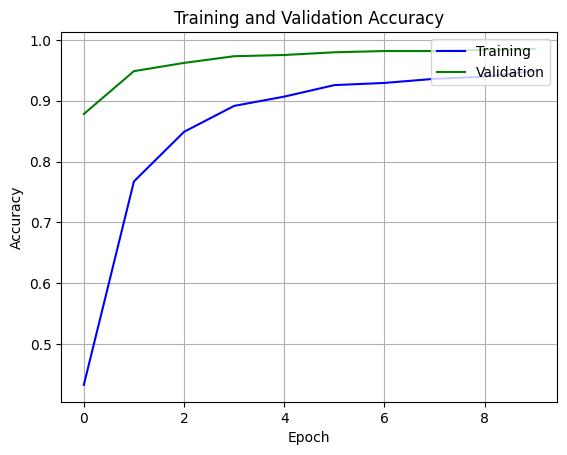

In [18]:
import matplotlib.pyplot as plt

_ = model.predict(test_images_cnn[:1])

plt.plot(fit_model.history['accuracy'], c="b", label='Train Accuracy')
plt.plot(fit_model.history['val_accuracy'], c="g", label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.grid()
plt.savefig('../output/accuracy_plot.png', dpi=150)
plt.show()

# Evaluation

In [20]:
ACC = model.evaluate(test_images_cnn, test_labels, verbose=0)
print(f"Test accuracy: {ACC[1]:.4f}")


Test accuracy: 0.9983


# Embedding

In [21]:
import tensorflow as tf

layer_names = [layer.name for layer in initial_model.layers]
print(layer_names)

dense_layers = [layer.name for layer in initial_model.layers 
                if isinstance(layer, tf.keras.layers.Dense)]
print("Available Dense layzers:", dense_layers)
selected_layer = dense_layers[-1]
print(selected_layer)


['conv2d', 'max_pooling2d', 'dropout', 'conv2d_1', 'max_pooling2d_1', 'dropout_1', 'flatten', 'dense', 'dropout_2', 'dense_1']
Available Dense layzers: ['dense', 'dense_1']
dense_1


In [22]:
import tensorflow as tf

embedding_model = tf.keras.Model(
    inputs=initial_model.inputs, 
    outputs=initial_model.get_layer(selected_layer).output
    )
train_embeddings = embedding_model.predict(
    train_images.reshape(-1,28,28,1)
    )  # shape (60000, 128      )

  90/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

2026-06-22 13:47:04.800697: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


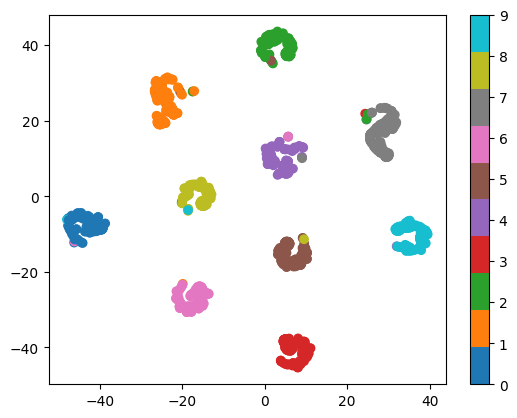

In [23]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

train_labels = labels_extractor(trainset)

tsne = TSNE(n_components=2)
embeddings_2d = tsne.fit_transform(train_embeddings[:1000])  # Only first n-ones

plt.scatter(
    embeddings_2d[:, 0], 
    embeddings_2d[:, 1], 
    c=train_labels[:1000], 
    cmap='tab10'
    )
plt.colorbar()
plt.show()

#bit of a cheating :)

Every point is the 2d-projection from `dense_2` layer within the initial model. We can already see the digits by their colours and how for instance `4` and `9` are way too close and the model may be confused about those labels (the result labels). 

So this is a visualization that allows us to understand _how good the model is acting_, and the overlappings will be the places where I shall take attention to. 

# Projections and clusterization

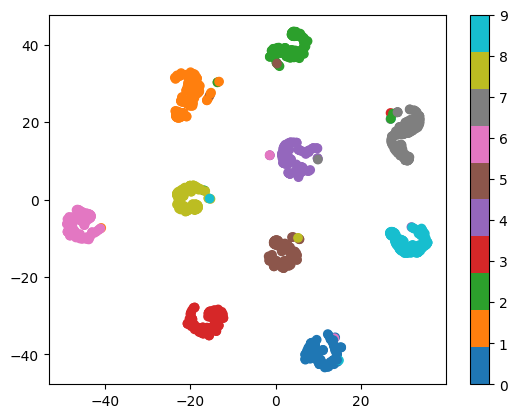

In [57]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

train_labels = labels_extractor(trainset)

tsne = TSNE(n_components=2)
embeddings_2d = tsne.fit_transform(train_embeddings[:1000])  # Only first n-ones

plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=train_labels[:1000], cmap='tab10')
plt.colorbar()
plt.show()

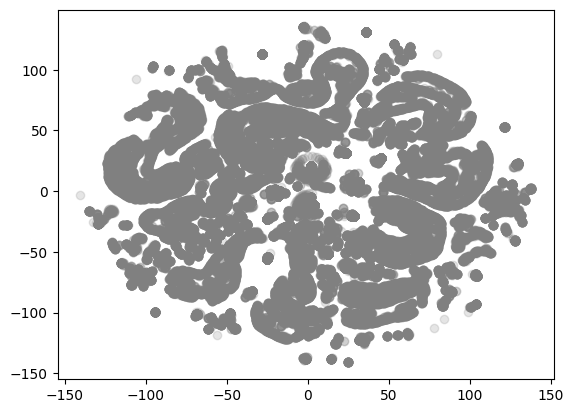

In [50]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

n_components = min(
    50, 
    train_embeddings.shape[0],
    train_embeddings.shape[1]
    )
pca = PCA(n_components=n_components)
train_pca = pca.fit_transform(train_embeddings)

tsne = TSNE(n_components=2, random_state=42)
train_tsne = tsne.fit_transform(train_pca)

# Visualization
plt.scatter(
    train_tsne[:,0], 
    train_tsne[:,1],
    c='gray',
    alpha=0.2
    )
plt.show()

# Clustering
kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
    )
cluster_labels = kmeans.fit_predict(train_embeddings)  # o usar train_pca

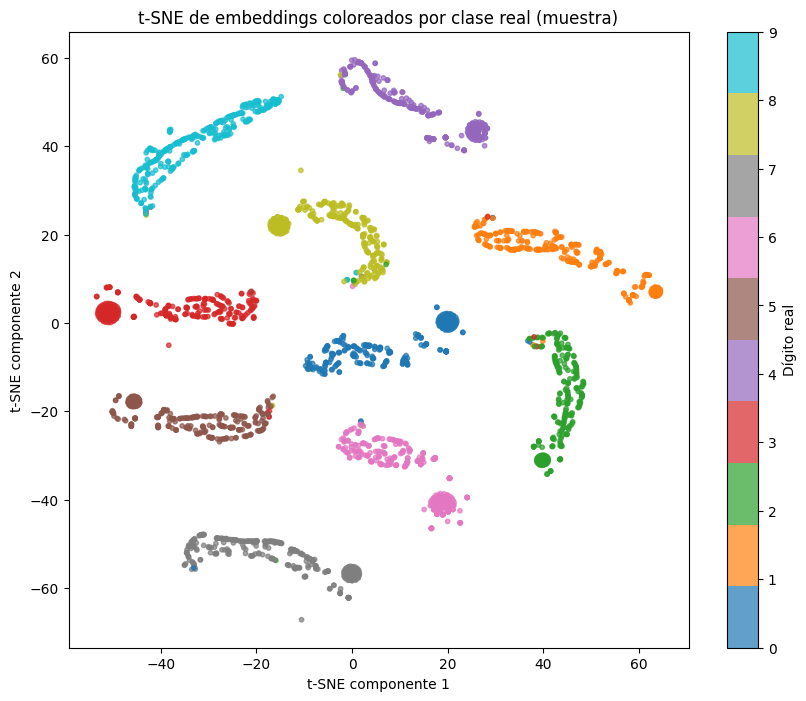

In [51]:
# Asumimos que train_embeddings y train_true_labels existen (groundtruth, solo para evaluación)
# randomization haciendo trampa porque se usan las true_labels

train_true_labels = train_labels
n_components = min(
    50, 
    train_embeddings.shape[0],
    train_embeddings.shape[1]
    )


sample_size = 3000   # ajustar según memoria/tiempo
np.random.seed(42)
indices = np.random.choice(train_embeddings.shape[0], sample_size, replace=False)
sample_embeddings = train_embeddings[indices]
sample_true_labels = train_true_labels[indices]   # solo para inspección


pca = PCA(n_components=n_components)   
sample_pca = pca.fit_transform(sample_embeddings)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
sample_tsne = tsne.fit_transform(sample_pca)


plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    sample_tsne[:, 0], 
    sample_tsne[:, 1], 
    c=sample_true_labels,
    cmap='tab10',
    alpha=0.7,
    s=10
    )
plt.colorbar(scatter, ticks=range(10), label='Dígito real')
plt.title("t‑SNE de embeddings coloreados por clase real (muestra)")
plt.xlabel("t‑SNE componente 1")
plt.ylabel("t‑SNE componente 2")
plt.show()

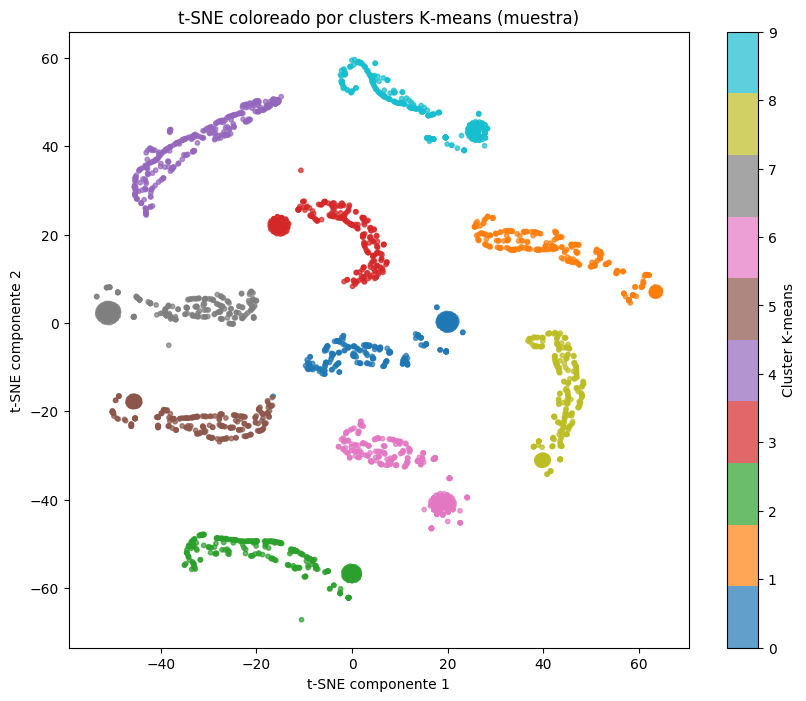

In [52]:
#6. Clustering con K‑means (sobre los embeddings originales, no sobre la proyección)
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
# Si quieres clustering sobre la muestra, pero luego asignarás a todo el conjunto
sample_cluster_labels = kmeans.fit_predict(sample_embeddings)  # o usar sample_pca

#7. Visualizar por clusters (aún sin asignar clases)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(sample_tsne[:, 0], sample_tsne[:, 1], 
                      c=sample_cluster_labels, cmap='tab10', alpha=0.7, s=10)
plt.colorbar(scatter, ticks=range(10), label='Cluster K‑means')
plt.title("t‑SNE coloreado por clusters K‑means (muestra)")
plt.xlabel("t‑SNE componente 1")
plt.ylabel("t‑SNE componente 2")
plt.show()



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


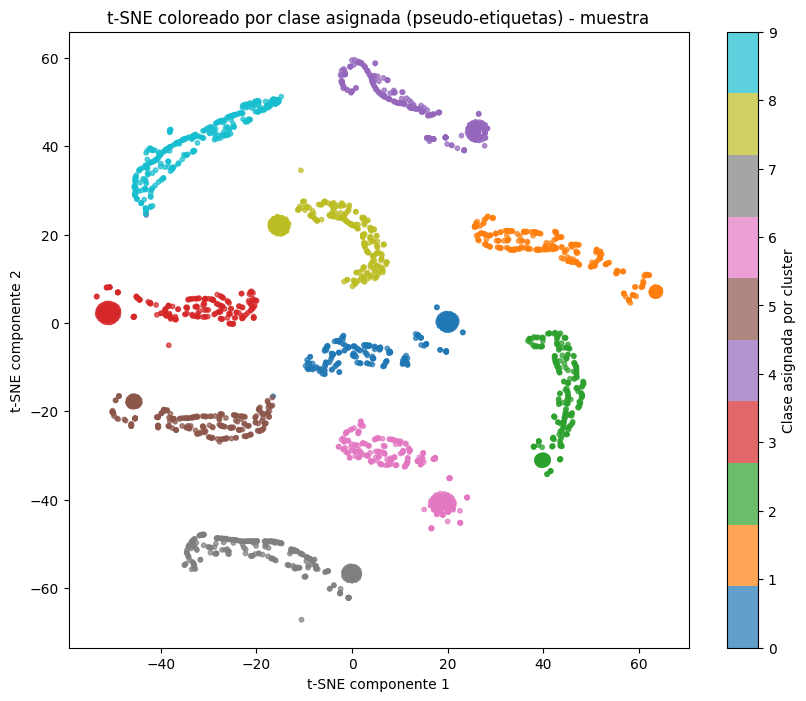

In [53]:
#8. Asignar clases a los clusters usando la semilla (conjunto de test)
# Obtener embeddings de la semilla (test) usando el mismo modelo de embedding
seed_embeddings = embedding_model.predict(test_images.reshape(-1,28,28,1))  # shape (10000, 128)
seed_labels = test_labels   # reales de test

# Calcular centroide de cada clase en el espacio de embeddings
class_means = {}
for c in range(10):
    mask = (seed_labels == c)
    if np.sum(mask) > 0:
        class_means[c] = np.mean(seed_embeddings[mask], axis=0)
    else:
        class_means[c] = None

# Calcular centroides de los clusters sobre el conjunto de entrenamiento completo
# (mejor usar todos los datos, no solo la muestra)
full_cluster_labels = kmeans.fit_predict(train_embeddings)  # o si ya lo tienes, reutilizar
cluster_centers = []
for k in range(10):
    mask = (full_cluster_labels == k)
    if np.sum(mask) > 0:
        center = np.mean(train_embeddings[mask], axis=0)
    else:
        center = None
    cluster_centers.append(center)

# Asignar a cada cluster la clase cuyo centroide esté más cerca (distancia euclídea)
cluster_to_class = {}
for k, center in enumerate(cluster_centers):
    if center is not None:
        distances = {c: np.linalg.norm(center - class_means[c]) for c in range(10) if class_means[c] is not None}
        assigned_class = min(distances, key=distances.get)
        cluster_to_class[k] = assigned_class
    else:
        # cluster vacío (poco probable)
        cluster_to_class[k] = -1

# Etiquetas pseudo para todo el conjunto de entrenamiento
pseudo_labels_full = np.array([cluster_to_class[cl] for cl in full_cluster_labels])


#9. Visualizar los puntos de la muestra coloreados por la clase asignada por cluster
# Para la muestra, obtenemos las clases asignadas
sample_pseudo_labels = pseudo_labels_full[indices]

plt.figure(figsize=(10, 8))
scatter = plt.scatter(sample_tsne[:, 0], sample_tsne[:, 1], 
                      c=sample_pseudo_labels, cmap='tab10', alpha=0.7, s=10)
plt.colorbar(scatter, ticks=range(10), label='Clase asignada por cluster')
plt.title("t‑SNE coloreado por clase asignada (pseudo‑etiquetas) - muestra")
plt.xlabel("t‑SNE componente 1")
plt.ylabel("t‑SNE componente 2")
plt.show()



In [54]:
import numpy as np
import umap
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

embeddings = embeddings_2d
n_neighbors=15 
min_dist=0.1

#projecting
reducer = umap.UMAP(
    n_neighbors=n_neighbors, 
    min_dist=min_dist
    )
project_to_2d = reducer.fit_transform(embeddings)

#clustering
n_clusters=10
kmeans = KMeans(
    n_clusters=n_clusters, 
    random_state=42
    )

cluster_labels = kmeans.fit_predict(embeddings)
cluster_embeddings = cluster_labels



/workspace/.venv/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:274: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/workspace/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


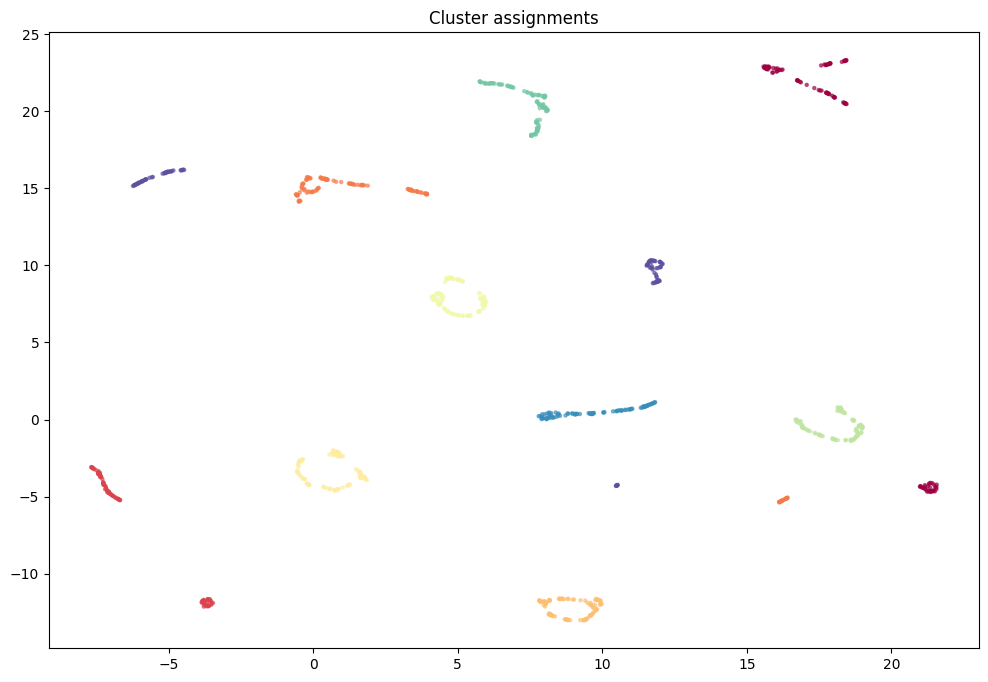

In [55]:
import matplotlib.pyplot as plt

projected_embeddings = project_to_2d
true_labels=None 
save_path=None

plt.figure(figsize=(12, 8))
    
if true_labels is not None:
    plt.scatter(
        projected_embeddings[:, 0],
        projected_embeddings[:, 1], 
        c=true_labels,
        cmap='Spectral',
        s=5,
        alpha=0.6
        )
    plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
    plt.title("True labels")
else:
    plt.scatter(
        projected_embeddings[:, 0],
        projected_embeddings[:, 1], 
        c=cluster_labels,
        cmap='Spectral', 
        s=5, 
        alpha=0.6
        )
    plt.title("Cluster assignments")

if save_path:
    plt.savefig(save_path)
else:
    plt.show()
plt.close()


Entrenando KMeans (k=10)...
 Clusters: 10, Ruido: 0, Silueta: 0.8207453489303589, ARI: None


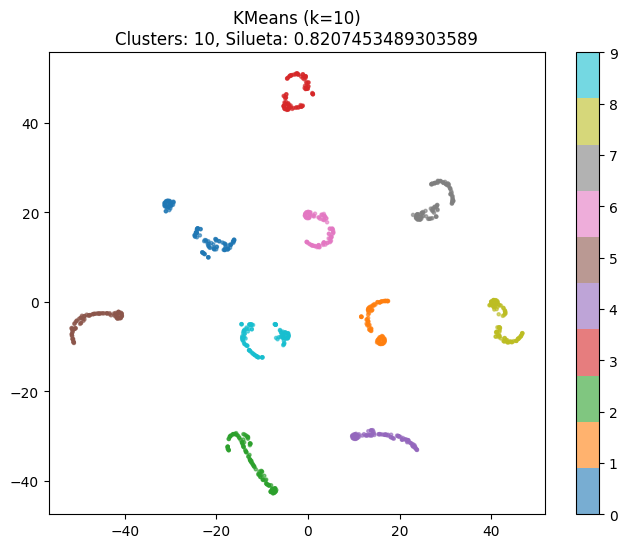

Entrenando DBSCAN (eps=0.5)...
 Clusters: 41, Ruido: 561, Silueta: -0.20712588727474213, ARI: None


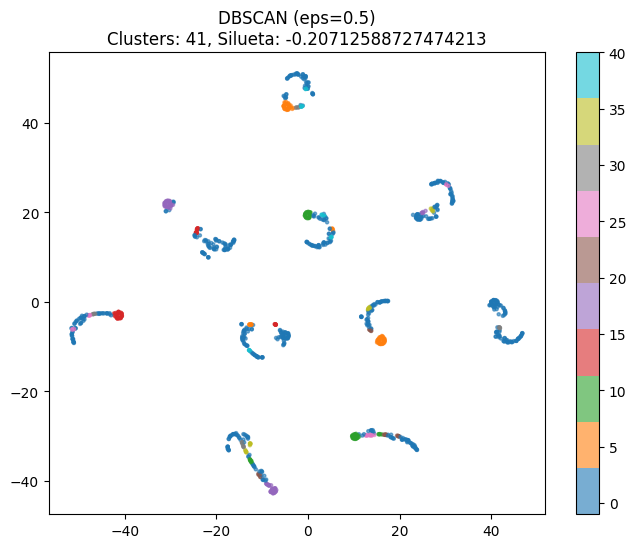

Entrenando DBSCAN (eps=0.7)...
 Clusters: 68, Ruido: 302, Silueta: 0.15454022586345673, ARI: None


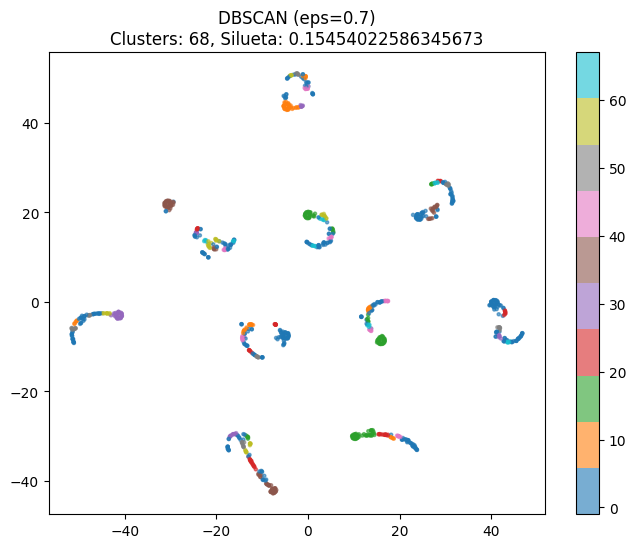

Entrenando Agglomerative (k=10)...
 Clusters: 10, Ruido: 0, Silueta: 0.8207453489303589, ARI: None


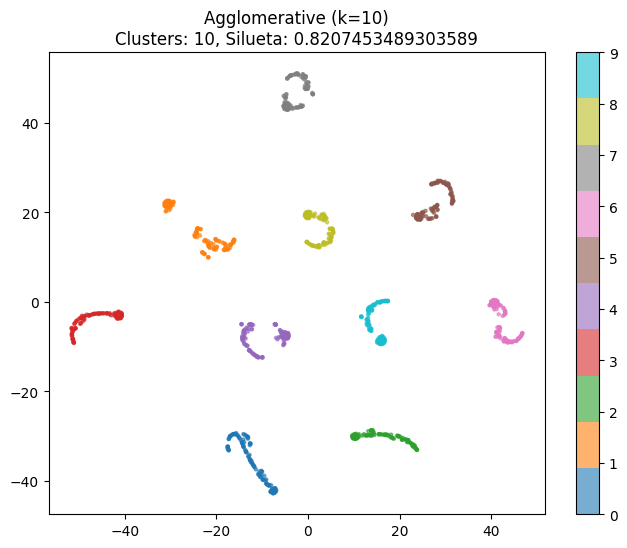

In [56]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
import numpy as np
import matplotlib.pyplot as plt


def evaluate_clustering(embeddings, true_labels=None, sample_size=3000):
    """
    Prueba varios algoritmos de clustering sobre los embeddings.
    Muestra métricas y visualiza con t‑SNE (o UMAP).
    """
    # Tomar una muestra si es muy grande
    if embeddings.shape[0] > sample_size:
        indices = np.random.choice(embeddings.shape[0], sample_size, replace=False)
        X_sample = embeddings[indices]
        y_true_sample = true_labels[indices] if true_labels is not None else None
    else:
        X_sample = embeddings
        y_true_sample = true_labels

    # Algoritmos a probar
    algorithms = {
        'KMeans (k=10)': KMeans(n_clusters=10, random_state=42, n_init=10),
        'DBSCAN (eps=0.5)': DBSCAN(eps=0.5, min_samples=5),
        'DBSCAN (eps=0.7)': DBSCAN(eps=0.7, min_samples=5),
        'Agglomerative (k=10)': AgglomerativeClustering(n_clusters=10),
    }

    # Reducción para visualización (t‑SNE)
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_vis = tsne.fit_transform(X_sample)

    results = {}
    for name, model in algorithms.items():
        print(f"Entrenando {name}...")
        labels = model.fit_predict(X_sample)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1) if hasattr(model, 'eps') else 0

        # Métricas
        sil = silhouette_score(X_sample, labels) if n_clusters >= 2 and n_clusters < len(X_sample) else None
        ari = adjusted_rand_score(y_true_sample, labels) if y_true_sample is not None else None

        results[name] = {
            'labels': labels,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette': sil,
            'ARI': ari
        }
        print(f" Clusters: {n_clusters}, Ruido: {n_noise}, Silueta: {sil}, ARI: {ari}")

        # Visualización
        plt.figure(figsize=(8,6))
        scatter = plt.scatter(X_vis[:,0], X_vis[:,1], c=labels, cmap='tab10', s=5, alpha=0.6)
        plt.colorbar(scatter)
        plt.title(f"{name}\nClusters: {n_clusters}, Silueta: {sil}")
        plt.show()

    return results

result = evaluate_clustering(embeddings=embeddings)


Checking out different clusterization methods, the worst is DBSCAN, but we can continue better with KMeans to the matter of this task. 

KMeans has:

Entrenando KMeans (k=10)...
 Clusters: 10, Ruido: 0, Silueta: 0.8165658116340637, ARI: None

no noise, simplicity and a hight silouette. 

# Automatic correction



In [59]:
# Training the Embedding Classifier on the Seed Set
from sklearn.linear_model import LogisticRegression

# seed_embeddings: (10000, D), seed_labels: (10000,)
classifier = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
classifier.fit(seed_embeddings, seed_labels)

LogisticRegression(max_iter=1000, multi_class='multinomial')

In [60]:
#Predict Class for Each Cluster Centroid
cluster_class_predictions = classifier.predict(cluster_centers)   # array of 10 digits
cluster_to_class = {i: int(cluster_class_predictions[i]) for i in range(10)}

In [61]:
# Assign Pseudo‑Labels to Training Samples
pseudo_labels = np.array([cluster_to_class[cl] for cl in cluster_labels])

In [62]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression

def assign_initial_labels(train_embeddings, seed_embeddings, seed_labels, n_clusters=10):
    """
    Cluster training embeddings and assign each cluster to a digit class
    using a classifier trained on seed embeddings.
    """
    # 1. Cluster training embeddings
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(train_embeddings)
    cluster_centers = kmeans.cluster_centers_

    # 2. Train embedding classifier on seed set
    clf = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
    clf.fit(seed_embeddings, seed_labels)

    # 3. Predict class for each cluster center
    cluster_classes = clf.predict(cluster_centers)

    # 4. Map cluster index to class
    cluster_to_class = {i: int(cluster_classes[i]) for i in range(n_clusters)}

    # 5. Assign pseudo-labels to training samples
    pseudo_labels = np.array([cluster_to_class[cl] for cl in cluster_labels])

    return pseudo_labels, cluster_to_class

In [63]:
pseudo_labels, cluster_to_class = assign_initial_labels(train_embeddings, seed_embeddings, seed_labels, n_clusters=10)

In [75]:
print(seed_images.shape)
print(train_images.shape)
print(seed_labels.shape)
print(pseudo_labels.shape)

(10000, 28, 28, 1)
(60000, 1, 28, 28)
(10000,)
(60000,)


In [88]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import models
import os

# parameters:
n_iter=5,
batch_size=256,
epochs_per_iter=2,
confidence_threshold=0.95

    
train_images_reshaped = np.transpose(train_images, (0, 2, 3, 1))
all_images = np.concatenate([seed_images, train_images_reshaped], axis=0)

all_labels = np.concatenate([seed_labels, pseudo_labels], axis=0)

current_labels = pseudo_labels.copy()

for iteration in range(5):
    print(f"Iteration {iteration+1}/{n_iter}")

    # Re‑train the model on the current labels
    model.fit(
        all_images, 
        all_labels,
        batch_size=32,#256,
        epochs=1,#2,
        verbose=1,
        shuffle=True
        )

    # Predict probabilities on training set only
    _ = model.predict(
        train_images,
        batch_size=32,#256, 
        verbose=0
        )
    
    preds = np.argmax(
        _, 
        axis=1
        )
    # max_probs = np.max(probs, axis=1)
    # # Find samples where model is confident and disagrees
    # confident_mask = max_probs >= confidence_threshold
    # disagree_mask = (preds != current_labels)

Iteration 1/(5,)
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.9777 - loss: 0.0701


2026-06-22 16:00:50.313982: W tensorflow/core/framework/op_kernel.cc:1840] OP_REQUIRES failed at conv_ops.cc:61 : INVALID_ARGUMENT: Depth of output must be a multiple of the number of groups: 32 vs 28

Stack trace for op definition: 
File "<frozen runpy>", line 198, in _run_module_as_main
File "<frozen runpy>", line 88, in _run_code
File "/workspace/.venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
File "/workspace/.venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1082, in launch_instance
File "/workspace/.venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 807, in start
File "/workspace/.venv/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
File "/usr/local/lib/python3.11/asyncio/base_events.py", line 608, in run_forever
File "/usr/local/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once
File "/usr/local/lib/python3.11/asyncio/events.py", line 84, in _run
File "/workspace/.venv/

InvalidArgumentError: Graph execution error:

Detected at node convolution defined at (most recent call last):
<stack traces unavailable>
Depth of output must be a multiple of the number of groups: 32 vs 28

Stack trace for op definition: 
File "<frozen runpy>", line 198, in _run_module_as_main
File "<frozen runpy>", line 88, in _run_code
File "/workspace/.venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
File "/workspace/.venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1082, in launch_instance
File "/workspace/.venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 807, in start
File "/workspace/.venv/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
File "/usr/local/lib/python3.11/asyncio/base_events.py", line 608, in run_forever
File "/usr/local/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once
File "/usr/local/lib/python3.11/asyncio/events.py", line 84, in _run
File "/workspace/

In [80]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import models

def self_training_correction(
    model,                 # compiled Keras model (seed‑trained)
    train_images,          # (60000,28,28,1) normalized
    pseudo_labels,         # initial labels (int)
    seed_images=None,      # optional (10000,28,28,1) with true labels
    seed_labels=None,      # if provided, we can include them in training
    n_iter=5,
    batch_size=256,
    epochs_per_iter=2,
    confidence_threshold=0.95
):
    """
    Self‑training refinement of pseudo‑labels using the model itself.
    Returns corrected labels and the final trained model.
    """
    # Combine seed and training data if seed provided
    if seed_images is not None:
        # train_images_reshaped = np.transpose(train_images, (0, 2, 3, 1))
        # quizás sea necesario reshaping
            
        all_images = np.concatenate([seed_images, train_images], axis=0)
        # For training, we assign true labels to seed, pseudo‑labels to train
        all_labels = np.concatenate([seed_labels, pseudo_labels], axis=0)
    else:
        all_images = train_images
        all_labels = pseudo_labels

    # We'll keep a copy of the current pseudo‑labels for updating
    current_labels = pseudo_labels.copy()

    for iteration in range(n_iter):
        print(f"Iteration {iteration+1}/{n_iter}")

        # Re‑train the model on the current labels
        model.fit(
            all_images, all_labels,
            batch_size=batch_size,
            epochs=epochs_per_iter,
            verbose=1,
            shuffle=True
        )

        # Predict probabilities on training set only
        probs = model.predict(train_images, batch_size=batch_size, verbose=0)
        preds = np.argmax(probs, axis=1)
        max_probs = np.max(probs, axis=1)

        # Find samples where model is confident and disagrees
        confident_mask = max_probs >= confidence_threshold
        disagree_mask = (preds != current_labels)

        # Update labels for those samples
        change_indices = np.where(confident_mask & disagree_mask)[0]
        if len(change_indices) == 0:
            print("No label changes; stopping early.")
            break

        updated = 0
        for idx in change_indices:
            current_labels[idx] = preds[idx]
            updated += 1

        print(f"Updated {updated} labels in this iteration.")

        # Update all_labels for the next training round
        if seed_images is not None:
            # Rebuild all_labels: seed labels stay fixed, training labels become current_labels
            all_labels = np.concatenate([seed_labels, current_labels], axis=0)
        else:
            all_labels = current_labels

    return current_labels, model


# Hay errores
current_labels, model = self_training_correction(
    model,                 # compiled Keras model (seed‑trained)
    train_images,          # (60000,28,28,1) normalized
    pseudo_labels,         # initial labels (int)
    seed_images=None,      # optional (10000,28,28,1) with true labels
    seed_labels=None,      # if provided, we can include them in training
    n_iter=5,
    batch_size=256,
    epochs_per_iter=2,
    confidence_threshold=0.95
)

Iteration 1/5
Epoch 1/2


2026-06-22 15:50:23.275930: W tensorflow/core/framework/op_kernel.cc:1840] OP_REQUIRES failed at conv_ops.cc:61 : INVALID_ARGUMENT: Depth of output must be a multiple of the number of groups: 32 vs 28

Stack trace for op definition: 
File "<frozen runpy>", line 198, in _run_module_as_main
File "<frozen runpy>", line 88, in _run_code
File "/workspace/.venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
File "/workspace/.venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1082, in launch_instance
File "/workspace/.venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 807, in start
File "/workspace/.venv/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
File "/usr/local/lib/python3.11/asyncio/base_events.py", line 608, in run_forever
File "/usr/local/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once
File "/usr/local/lib/python3.11/asyncio/events.py", line 84, in _run
File "/workspace/.venv/

InvalidArgumentError: Graph execution error:

Detected at node convolution defined at (most recent call last):
<stack traces unavailable>
Depth of output must be a multiple of the number of groups: 32 vs 28

Stack trace for op definition: 
File "<frozen runpy>", line 198, in _run_module_as_main
File "<frozen runpy>", line 88, in _run_code
File "/workspace/.venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
File "/workspace/.venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1082, in launch_instance
File "/workspace/.venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 807, in start
File "/workspace/.venv/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
File "/usr/local/lib/python3.11/asyncio/base_events.py", line 608, in run_forever
File "/usr/local/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once
File "/usr/local/lib/python3.11/asyncio/events.py", line 84, in _run
File "/workspace/